# Tarea 2 — Elementos Finitos en Diseño Mecánico

## Problema 1: viga curva en voladizo


### 1. Datos y supuestos

La viga se representa como un cuarto de circunferencia de radio $R$, empotrada en $\theta=0$ y libre en $\theta=\pi/2$. La carga vertical $P$ actúa hacia abajo en el extremo libre. Se trabaja inicialmente en unidades SI.

Se supone comportamiento elástico lineal y pequeñas deformaciones. Para el futuro modelo MEF se utilizarán elementos de viga de Euler–Bernoulli de dos nodos.|

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Propiedades del problema (SI)
E = 210e9          # Pa
G = 80e9           # Pa
Sy = 300e6         # Pa
I = 2e6 * 1e-12    # 2·10^6 mm^4 -> m^4
A = 200e-6         # 200 mm^2 -> m^2
R = 1.0            # m
P = 1e3            # N
theta_max = np.pi / 2
L_arco = R * theta_max

print(f'Longitud del arco: {L_arco:.4f} m')
print(f'Rigidez axial EA: {E*A:.3e} N')
print(f'Rigidez a flexión EI: {E*I:.3e} N·m²')

Longitud del arco: 1.5708 m
Rigidez axial EA: 4.200e+07 N
Rigidez a flexión EI: 4.200e+05 N·m²


### 2. Geometría y discretizaciones propuestas

La línea media se parametriza mediante

$$x(\theta)=R\sin\theta, \qquad y(\theta)=R\cos\theta,$$

con $0\leq\theta\leq\pi/2$. Se consideran mallas de 4, 8 y 16 elementos. Esto permite estudiar simultáneamente la aproximación de la geometría curva mediante cuerdas rectas y la convergencia de la solución MEF.

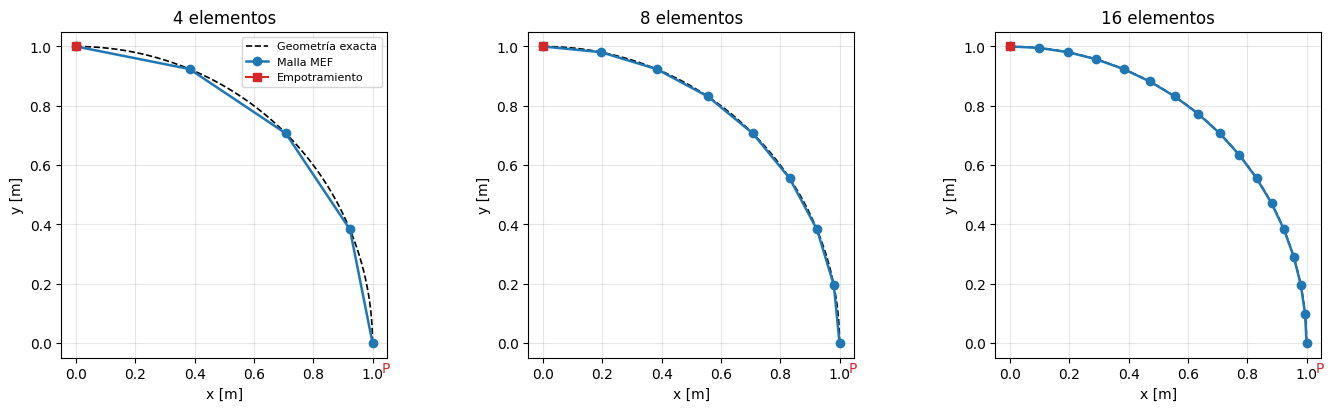

In [2]:
def nodos_arco(n_elementos, radio=R):
    theta = np.linspace(0.0, theta_max, n_elementos + 1)
    x = radio * np.sin(theta)
    y = radio * np.cos(theta)
    return theta, x, y

theta_ref = np.linspace(0.0, theta_max, 400)
x_ref = R * np.sin(theta_ref)
y_ref = R * np.cos(theta_ref)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, n_elem in zip(axes, [4, 8, 16]):
    theta_n, x_n, y_n = nodos_arco(n_elem)
    ax.plot(x_ref, y_ref, 'k--', lw=1.2, label='Geometría exacta')
    ax.plot(x_n, y_n, 'o-', lw=1.8, label='Malla MEF')
    ax.plot([0], [R], marker='s', color='tab:red', label='Empotramiento')
    ax.annotate('', xy=(R, -0.18), xytext=(R, 0.02),
                arrowprops=dict(arrowstyle='->', color='tab:red', lw=2))
    ax.text(R + 0.03, -0.10, 'P', color='tab:red')
    ax.set_title(f'{n_elem} elementos')
    ax.set_aspect('equal')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=8)
plt.show()

### 3. Esfuerzos internos preliminares por equilibrio

Se realiza un corte en una posición angular $\theta$ y se aísla el tramo comprendido entre el corte y el extremo libre. Con la convención local adoptada en este notebook se obtiene:

$$N(\theta)=-P\sin\theta,$$

$$V(\theta)=-P\cos\theta,$$

$$M(\theta)=PR(1-\sin\theta).$$

Los signos dependen de la orientación elegida para los ejes locales; sus magnitudes y condiciones de borde no cambian. En el empotramiento, $|V|=P$ y $|M|=PR$. En el extremo libre, $|N|=P$, mientras que $V=M=0$.

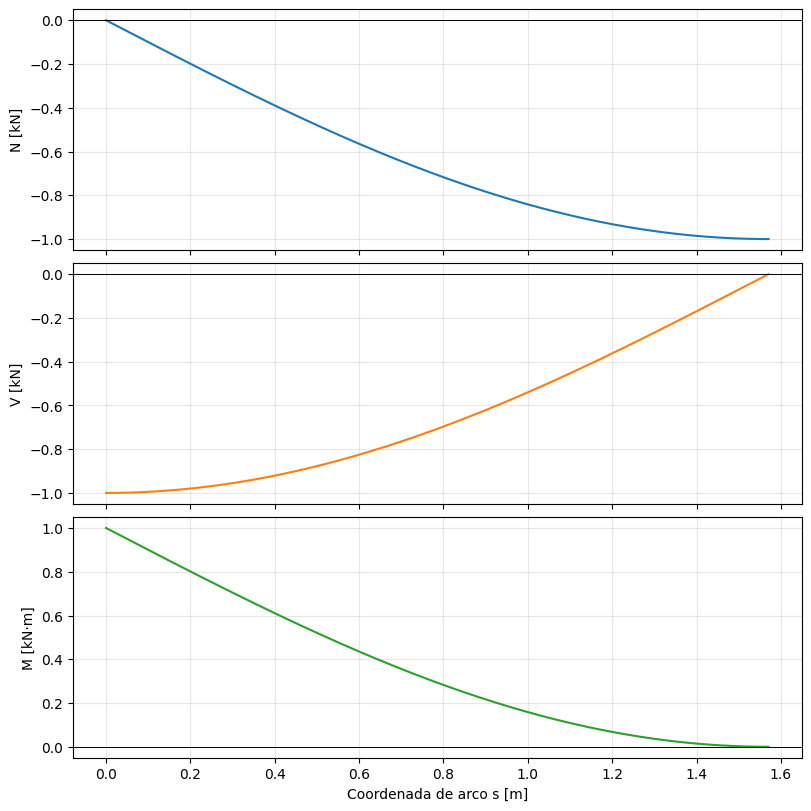

In [3]:
theta = np.linspace(0.0, theta_max, 400)
s = R * theta

N = -P * np.sin(theta)
V = -P * np.cos(theta)
M = P * R * (1.0 - np.sin(theta))

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True, constrained_layout=True)
axes[0].plot(s, N / 1e3, color='tab:blue')
axes[0].set_ylabel('N [kN]')
axes[1].plot(s, V / 1e3, color='tab:orange')
axes[1].set_ylabel('V [kN]')
axes[2].plot(s, M / 1e3, color='tab:green')
axes[2].set_ylabel('M [kN·m]')
axes[2].set_xlabel('Coordenada de arco s [m]')
for ax in axes:
    ax.axhline(0, color='k', lw=0.7)
    ax.grid(alpha=0.3)
plt.show()

## Punto de detención del avance

Hasta aquí quedan establecidos los datos, la geometría, las tres discretizaciones y una solución preliminar de los esfuerzos internos por equilibrio. El siguiente paso es formular el elemento de pórtico plano, transformar cada matriz local al sistema global, ensamblar $\mathbf K\mathbf U=\mathbf F$ e imponer el empotramiento. Después se compararán desplazamiento, rotación, momento y corte para las tres mallas con la solución analítica.